In [4]:
import pandas as pd

In [9]:
df = pd.read_csv('/Users/rubyestrickland/Desktop/EnvDataSci/HW05/LA_AQS_2023 (2).csv')
print(df.head())

   State Code  County Code  Site Number  Parameter Code  POC  Latitude  \
0           6           37         1103           68103    1  34.06659   
1           6           37         1103           42602    3  34.06659   
2           6           37         1103           62201    1  34.06659   
3           6           37         1103           62101    1  34.06659   
4           6           37         1103           42603    1  34.06659   

   Longitude  Datum            Parameter Name Duration Description  ... AQI  \
0 -118.22688  WGS84   Ambient Min Temperature              24 HOUR  ...   .   
1 -118.22688  WGS84    Nitrogen dioxide (NO2)               1 HOUR  ...  16   
2 -118.22688  WGS84         Relative Humidity               1 HOUR  ...   .   
3 -118.22688  WGS84       Outdoor Temperature               1 HOUR  ...   .   
4 -118.22688  WGS84  Oxides of nitrogen (NOx)               1 HOUR  ...   .   

  Daily Criteria Indicator  Tribe Name  State Name  County Name    City Name  \


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
df_O3 = df[(df['Parameter Name']=='Ozone') & (df['Duration Description']=='1 HOUR')]

[Text(0.5, 9.444444444444427, 'Mean Ozone (O3) (ppm)'),
 Text(13.444444444444445, 0.5, 'Count')]

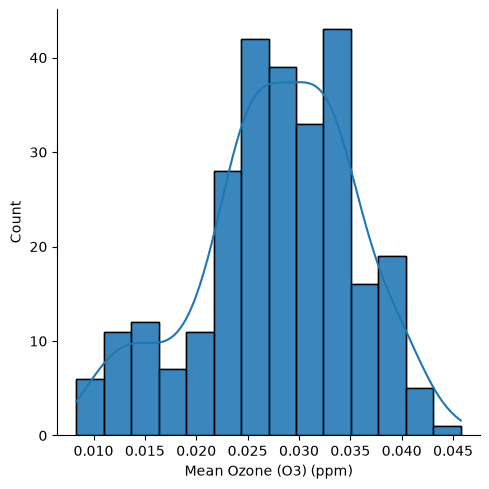

In [22]:
sns.displot( data=df_O3["Arithmetic Mean"], kde=True )
ax = sns.histplot(data=df_O3, x="Arithmetic Mean")
ax.set(xlabel="Mean Ozone (O3) (ppm)", ylabel="Count")

In [24]:
df_NO2 = df[(df['Parameter Name'] == 'Nitrogen dioxide (NO2)') & (df['Duration Description'] == '1 HOUR')]

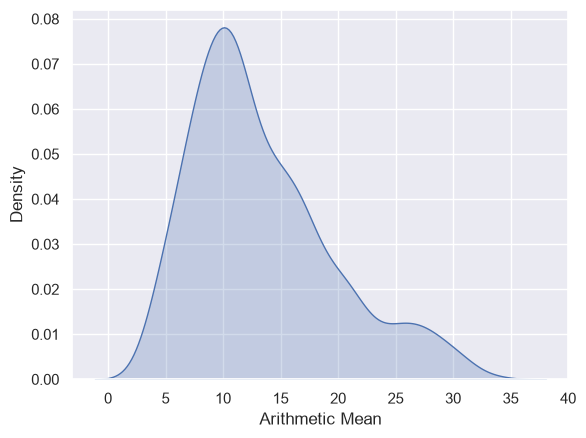

In [26]:
sns.set_theme(style="darkgrid")
sns.kdeplot(df_NO2['Arithmetic Mean'], fill=True)
plt.show()

[Text(0.5, 0, 'Mean Nitrogen Dioxidie (NO2) (ppb)'), Text(0, 0.5, 'Count')]

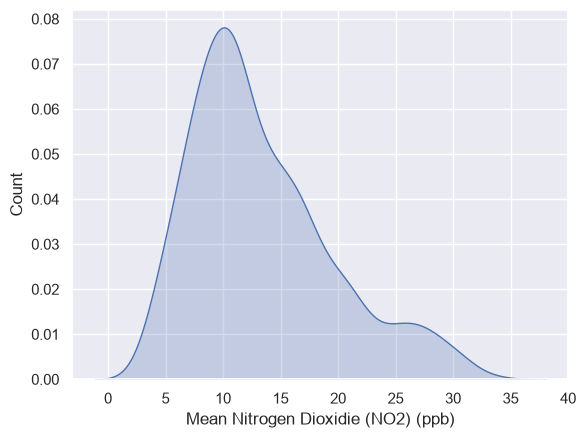

In [28]:
ax = sns.kdeplot(data=df_NO2, x="Arithmetic Mean",fill=True)
ax.set(xlabel="Mean Nitrogen Dioxidie (NO2) (ppb)", ylabel="Count")

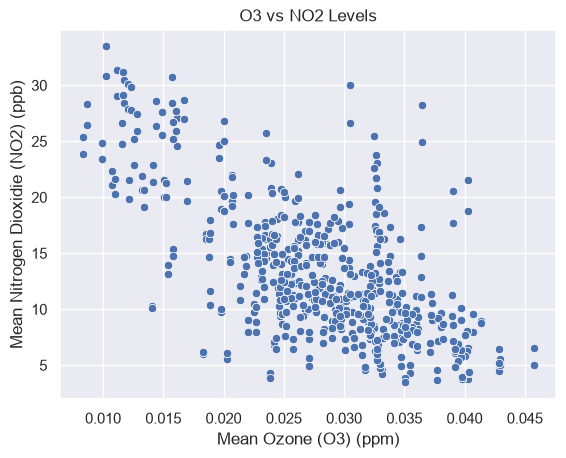

In [34]:
df_combined = pd.merge(
    df_O3, 
    df_NO2, 
    on="Day In Year (Local)",         
    suffixes=("_O3", "_NO2"))
sns.scatterplot(
    data=df_combined, 
    x="Arithmetic Mean_O3", 
    y="Arithmetic Mean_NO2")
plt.xlabel("Mean Ozone (O3) (ppm)")
plt.ylabel("Mean Nitrogen Dioxidie (NO2) (ppb)")
plt.title("O3 vs NO2 Levels")
plt.show()


In [53]:
highO3_df = df_O3[df_O3["Arithmetic Mean"] > 0.035]

In [54]:
print(highO3_df.head())

      State Code  County Code  Site Number  Parameter Code  POC  Latitude  \
4651           6           37         1103           44201    1  34.06659   
4928           6           37         1103           44201    1  34.06659   
5235           6           37         1103           44201    1  34.06659   
7130           6           37         1103           44201    1  34.06659   
7337           6           37         1103           44201    1  34.06659   

      Longitude  Datum Parameter Name Duration Description  ... AQI  \
4651 -118.22688  WGS84          Ozone               1 HOUR  ...   .   
4928 -118.22688  WGS84          Ozone               1 HOUR  ...   .   
5235 -118.22688  WGS84          Ozone               1 HOUR  ...   .   
7130 -118.22688  WGS84          Ozone               1 HOUR  ...   .   
7337 -118.22688  WGS84          Ozone               1 HOUR  ...   .   

     Daily Criteria Indicator  Tribe Name  State Name  County Name  \
4651                        Y         Na

In [55]:
highO3_df['Date (Local)']=pd.to_datetime(highO3_df['Date (Local)'])

In [58]:
highO3_df["Month"] = highO3_df["Date (Local)"].dt.month 
month_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

[Text(0.5, 0, 'Month'),
 Text(0, 0.5, 'Number of Days (O3 > 35 ppb)'),
 Text(0.5, 1.0, 'Number of Days per Month with O3 > 35 ppb')]

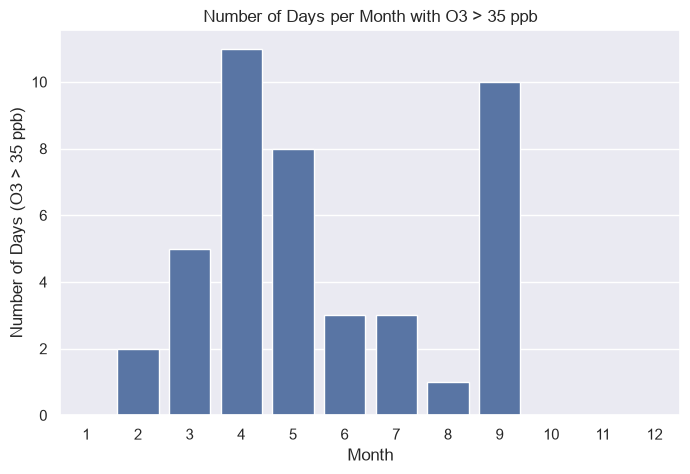

In [61]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=highO3_df, 
    x='Month', 
    order=month_order, 
    ax=ax)

ax.set(
    xlabel='Month', 
    ylabel='Number of Days (O3 > 35 ppb)', 
    title='Number of Days per Month with O3 > 35 ppb')

In [62]:
df_ml = pd.read_csv('/Users/rubyestrickland/Desktop/EnvDataSci/HW05/ManuaLoa_CO2.csv')
print(df_ml.head())

   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.70          314.43     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.71     -1 -9.99 -0.99
3  1958      6     1958.4548   317.24          315.14     -1 -9.99 -0.99
4  1958      7     1958.5370   315.86          315.18     -1 -9.99 -0.99


In [63]:
df_ml.columns

Index(['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays',
       'sdev', 'unc'],
      dtype='str')

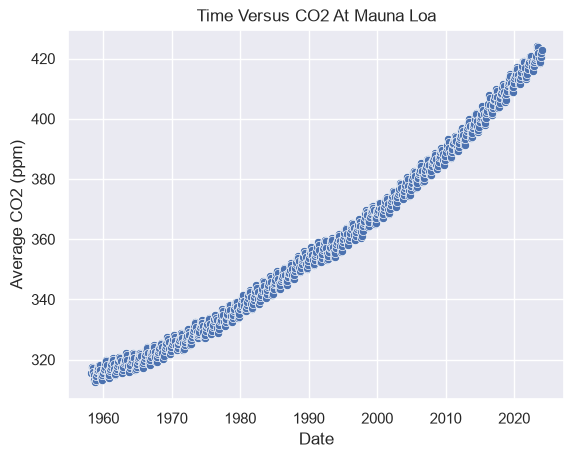

In [65]:
sns.scatterplot(x=df_ml["decimal date"], y=df_ml["average"])
plt.xlabel("Date")
plt.ylabel("Average CO2 (ppm)")
plt.title("Time Versus CO2 At Mauna Loa")
plt.show()

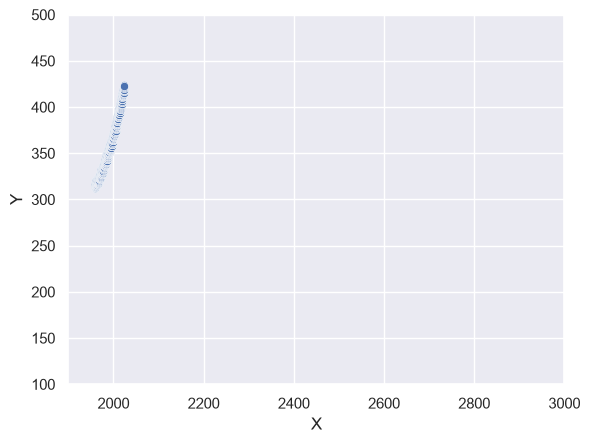

In [69]:
ax = sns.scatterplot(x=df_ml["decimal date"], y=df_ml["average"])
ax.set(
    xlabel="X",
    ylabel="Y",
    xlim=(1900, 3000),
    ylim=(100, 500),
)
plt.show()